In [ ]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest


In [24]:
# load dataset
from ucimlrepo import fetch_ucirepo


In [25]:
# load the dataset
air_quality = fetch_ucirepo(id=360)

# convert to pandas dataframe
df = air_quality.data.features

df.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [26]:
#select the specific features for analomy detection
features=df[['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']]
features.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166,113
1,2.0,9.4,103,92
2,2.2,9.0,131,114
3,2.2,9.2,172,122
4,1.6,6.5,131,116


In [27]:
# check for missing values
features.isnull().sum()

CO(GT)      0
C6H6(GT)    0
NOx(GT)     0
NO2(GT)     0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


In [29]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CO(GT)    9357 non-null   float64
 1   C6H6(GT)  9357 non-null   float64
 2   NOx(GT)   9357 non-null   int64  
 3   NO2(GT)   9357 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 292.5 KB


In [31]:
# parameters for isolation forest
n_estimators = 100   # no:of trees in the forest
contamination = 0.01  # expected proportion of outliers in the data
sample_size = 256   # number of samples to draw from the data to train each base estimator

In [34]:
# train the isolation forest model
model = IsolationForest(n_estimators=n_estimators, contamination=contamination, max_samples=sample_size, random_state=42)
model.fit(features)


# predict anomalies
anomaly_labels = model.predict(features)

# -1 indicates an anomaly, 1 indicates normal stored the anomaly labels in the original dataframe
features['anomaly'] = anomaly_labels


C:\Users\hares\AppData\Local\Temp\ipykernel_2888\1995029521.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['anomaly'] = anomaly_labels


In [33]:
features.head()

,CO(GT),C6H6(GT),NOx(GT),NO2(GT),anomaly
0,2.6,11.9,166,113,1
1,2.0,9.4,103,92,1
2,2.2,9.0,131,114,1
3,2.2,9.2,172,122,1
4,1.6,6.5,131,116,1


In [36]:
# count ananomalies
anomaly_counts = features['anomaly'].value_counts()
print(anomaly_counts)

anomaly
 1    9263
-1      94
Name: count, dtype: int64


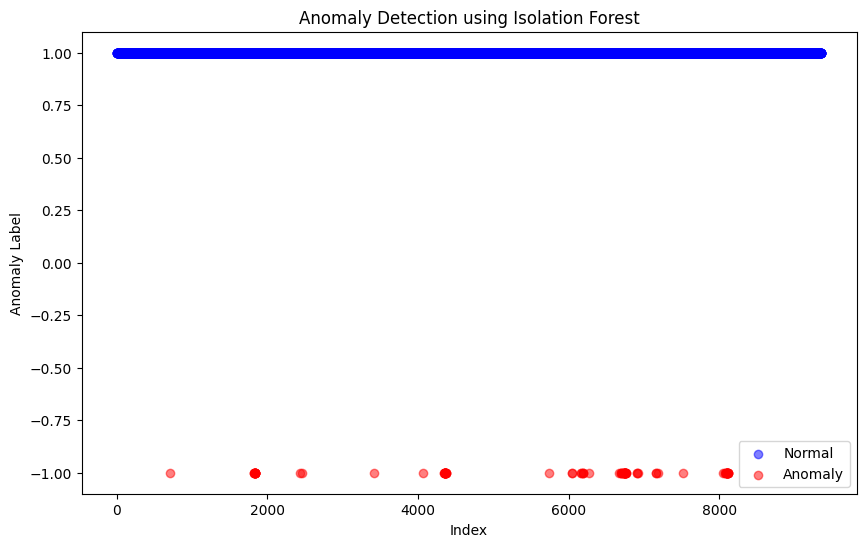

In [40]:
# visualize anomalies using scatter plot
plt.figure(figsize=(10, 6))

# plot normal instances
normal_data = features[features['anomaly' ] == 1]
plt.scatter(normal_data.index, normal_data['anomaly'], color='blue', label='Normal', alpha=0.5)

# plot anomalies
anomalies = features[features['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly'], color='red', label='Anomaly', alpha=0.5)

plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Index')
plt.ylabel('Anomaly Label')
plt.legend()
plt.show()



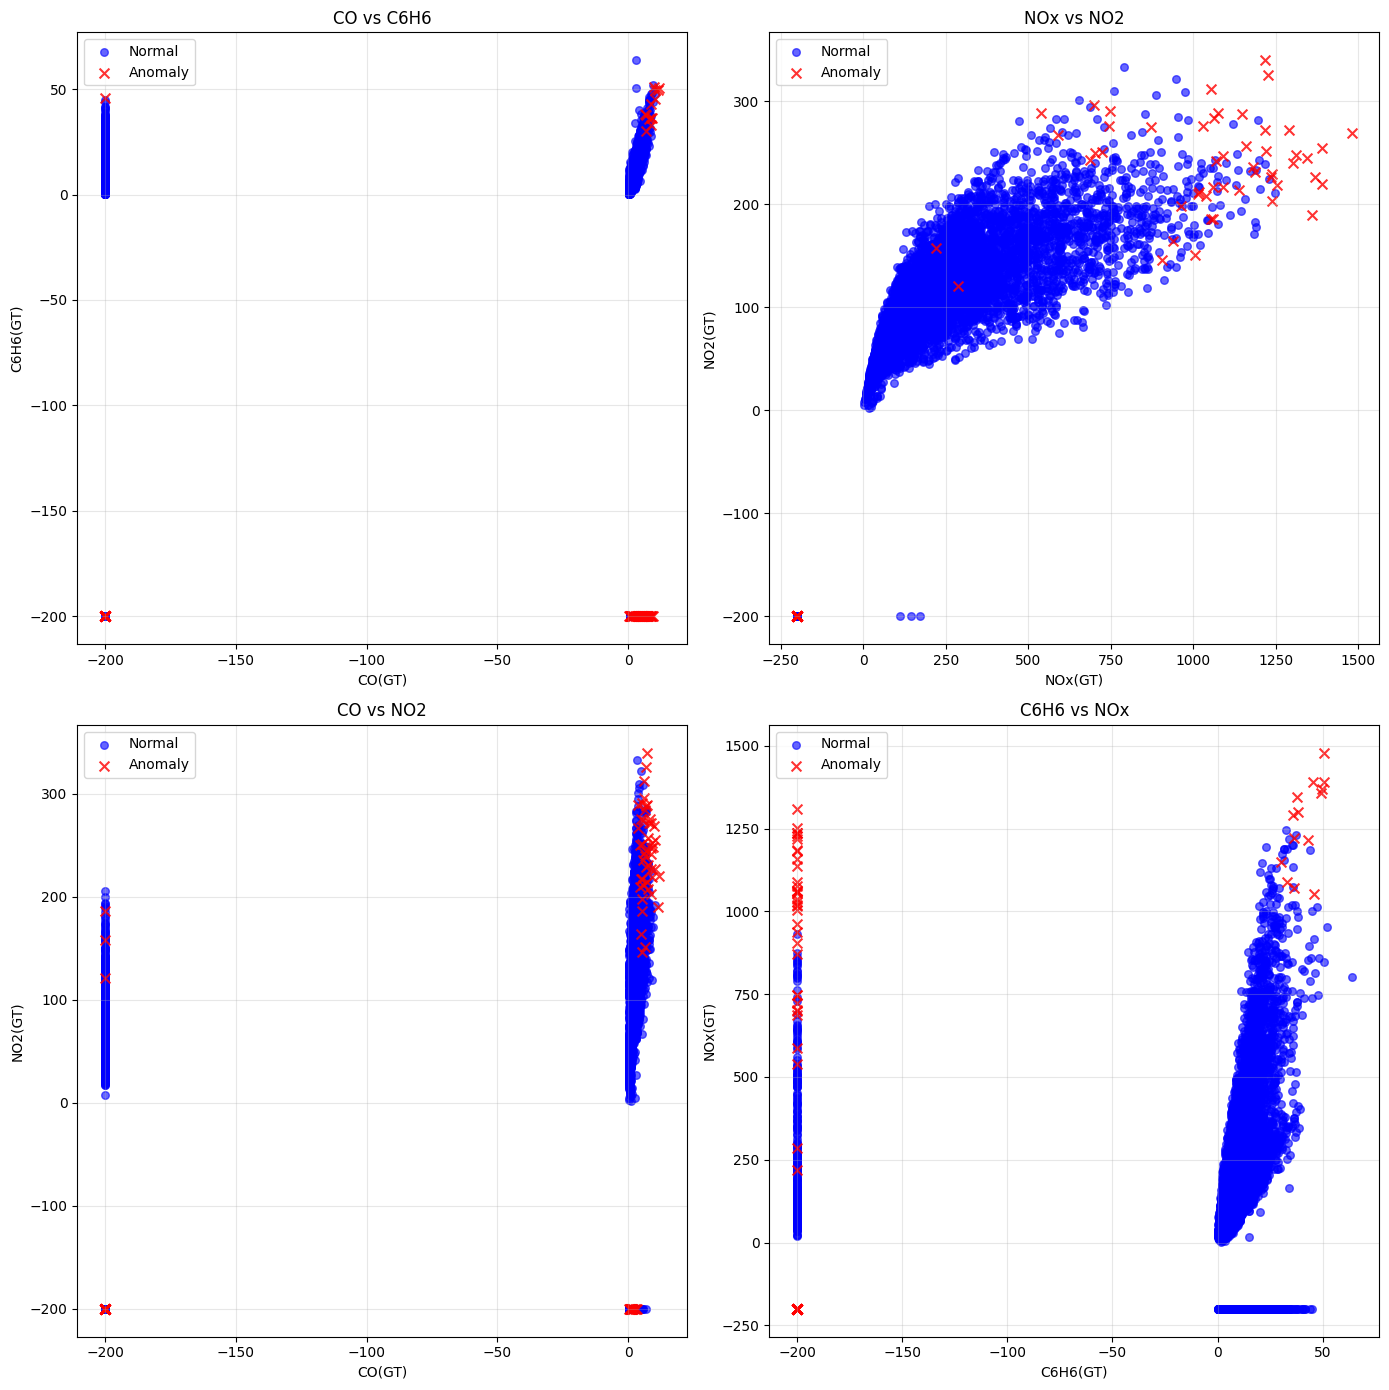

In [58]:

# Visualize anomalies - Multiple feature comparisons
fig, axes = plt.subplots(2,2, figsize=(14, 14))

normal = features[features['anomaly' ] == 1]
anomaly = features[features['anomaly' ] == -1]

# Plot 1: CO vs C6H6
axes[0,0].scatter(normal['CO(GT)'], normal['C6H6(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[0,0].scatter(anomaly['CO(GT)'], anomaly['C6H6(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0,0].set_xlabel('CO(GT)')
axes[0,0].set_ylabel('C6H6(GT)')
axes[0,0].set_title('CO vs C6H6' )
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: NOx vs NO2
axes[0,1].scatter(normal['NOx(GT)'], normal['NO2(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[0,1].scatter(anomaly['NOx(GT)'], anomaly['NO2(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[0,1].set_xlabel('NOx(GT)')
axes[0,1].set_ylabel('NO2(GT)')
axes[0,1].set_title('NOx vs NO2')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# plot 3 : CO vs NO2

axes[1,0].scatter(normal['CO(GT)'], normal['NO2(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[1,0].scatter(anomaly['CO(GT)'], anomaly['NO2(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1,0].set_xlabel('CO(GT)')
axes[1,0].set_ylabel('NO2(GT)')
axes[1,0].set_title('CO vs NO2')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# plot 4 : C6H6 vs NOx
axes[1,1].scatter(normal['C6H6(GT)'], normal['NOx(GT)'], color='blue', label='Normal', alpha=0.6, s=30)
axes[1,1].scatter(anomaly['C6H6(GT)'], anomaly['NOx(GT)'], color='red', label='Anomaly', alpha=0.8, s=50, marker='x')
axes[1,1].set_xlabel('C6H6(GT)')
axes[1,1].set_ylabel('NOx(GT)')
axes[1,1].set_title('C6H6 vs NOx')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)



plt.tight_layout()

plt.show()


In [61]:
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio
pio.renderers.default = "browser"

 
# Separate normal and anomaly
normal = features[features['anomaly'] == 1]
anomaly = features[features['anomaly'] == -1]
 
fig = go.Figure()
 
# Normal points
fig.add_trace(go.Scatter3d(
    x=normal['CO(GT)'],
    y=normal['C6H6(GT)'],
    z=normal['NOx(GT)'],
    mode='markers',
    name='Normal',
    marker=dict(
        size=6,
        color=normal['NO2(GT)'],   # 4th dimension as color
        colorscale='Blues',
        opacity=0.6,
        colorbar=dict(title='NO2(GT)')
    )
))
 
# Anomaly points
fig.add_trace(go.Scatter3d(
    x=anomaly['CO(GT)'],
    y=anomaly['C6H6(GT)'],
    z=anomaly['NOx(GT)'],
    mode='markers',
    name='Anomaly',
    marker=dict(
        size=8,
        color=anomaly['NO2(GT)'],
        colorscale='Reds',
        opacity=0.9,
        symbol='diamond'
    )
))
 
# Layout
fig.update_layout(
    title='4D Scatter Plot (Color = NO2(GT))',
    scene=dict(
        xaxis_title='CO(GT)',
        yaxis_title='C6H6(GT)',
        zaxis_title='NOx(GT)'
    ),
    width=900,
    height=700
)
 
fig.show()
 
 